In [1]:
import os

dataset_path = r"C:\Users\User\plantvillage\plantvillage dataset\color"

classes = sorted(os.listdir(dataset_path))
print(f"Total classes: {len(classes)}")
print("\nFirst 5 classes:")
for c in classes[:5]:
    print(f"  - {c}")

Total classes: 38

First 5 classes:
  - Apple___Apple_scab
  - Apple___Black_rot
  - Apple___Cedar_apple_rust
  - Apple___healthy
  - Blueberry___healthy


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

random.seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATASET_PATH = Path(r"C:\Users\User\plantvillage\plantvillage dataset\color")

print("All imports successful ✓")

All imports successful ✓


In [4]:
class_counts = {}
for cls in sorted(DATASET_PATH.iterdir()):
    imgs = list(cls.glob("*.jpg"))
    class_counts[cls.name] = len(imgs)

df = pd.DataFrame(list(class_counts.items()), columns=["class", "count"])
df = df.sort_values("count", ascending=False).reset_index(drop=True)

print(f"Total images: {df['count'].sum():,}")
print(f"Total classes: {len(df)}")
print(f"Avg images per class: {df['count'].mean():.0f}")
print(f"Min: {df['count'].min()}  |  Max: {df['count'].max()}")
print()
print(df.to_string())

Total images: 54,303
Total classes: 38
Avg images per class: 1429
Min: 152  |  Max: 5507

                                                 class  count
0             Orange___Haunglongbing_(Citrus_greening)   5507
1               Tomato___Tomato_Yellow_Leaf_Curl_Virus   5357
2                                    Soybean___healthy   5090
3                               Peach___Bacterial_spot   2297
4                              Tomato___Bacterial_spot   2127
5                                 Tomato___Late_blight   1908
6                              Squash___Powdery_mildew   1835
7                          Tomato___Septoria_leaf_spot   1771
8        Tomato___Spider_mites Two-spotted_spider_mite   1676
9                                      Apple___healthy   1645
10                                    Tomato___healthy   1591
11                                 Blueberry___healthy   1502
12                              Pepper,_bell___healthy   1477
13                                Tomato__

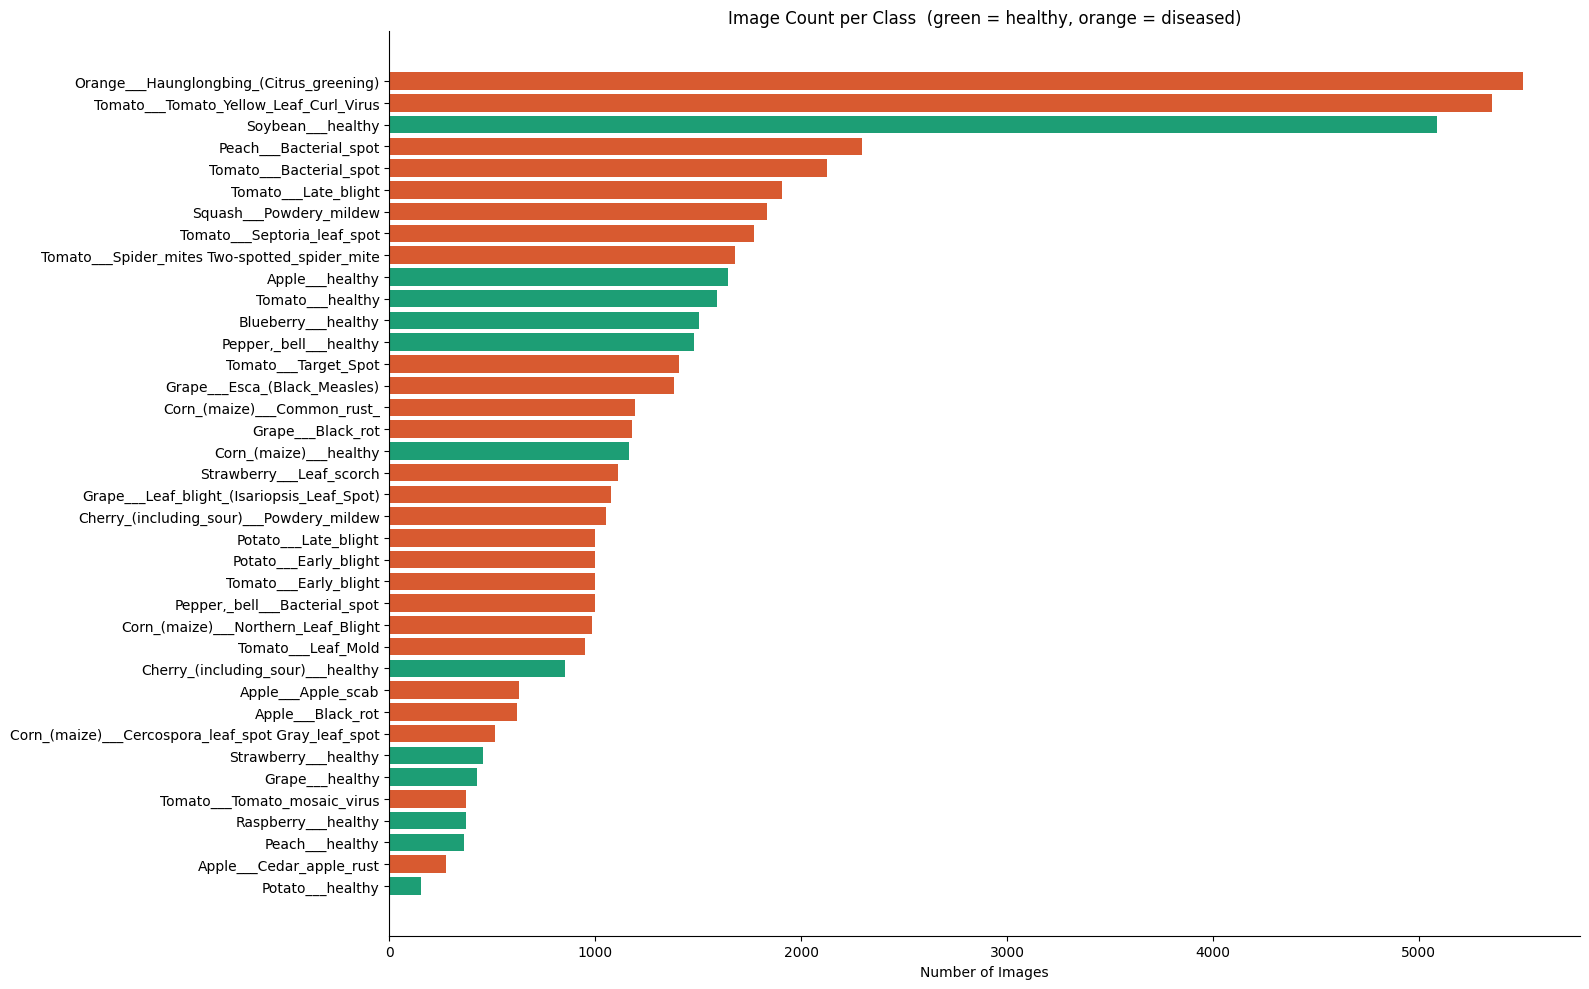

Healthy images:  15,083 (27.8%)
Diseased images: 39,220 (72.2%)


In [5]:
plt.figure(figsize=(16, 10))
colors = ['#1d9e75' if 'healthy' in c.lower() else '#d85a30' for c in df['class']]
plt.barh(df['class'], df['count'], color=colors)
plt.xlabel("Number of Images")
plt.title("Image Count per Class  (green = healthy, orange = diseased)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Healthy vs diseased split
healthy = df[df['class'].str.contains('healthy', case=False)]['count'].sum()
diseased = df[~df['class'].str.contains('healthy', case=False)]['count'].sum()
total = healthy + diseased
print(f"Healthy images:  {healthy:,} ({100*healthy/total:.1f}%)")
print(f"Diseased images: {diseased:,} ({100*diseased/total:.1f}%)")

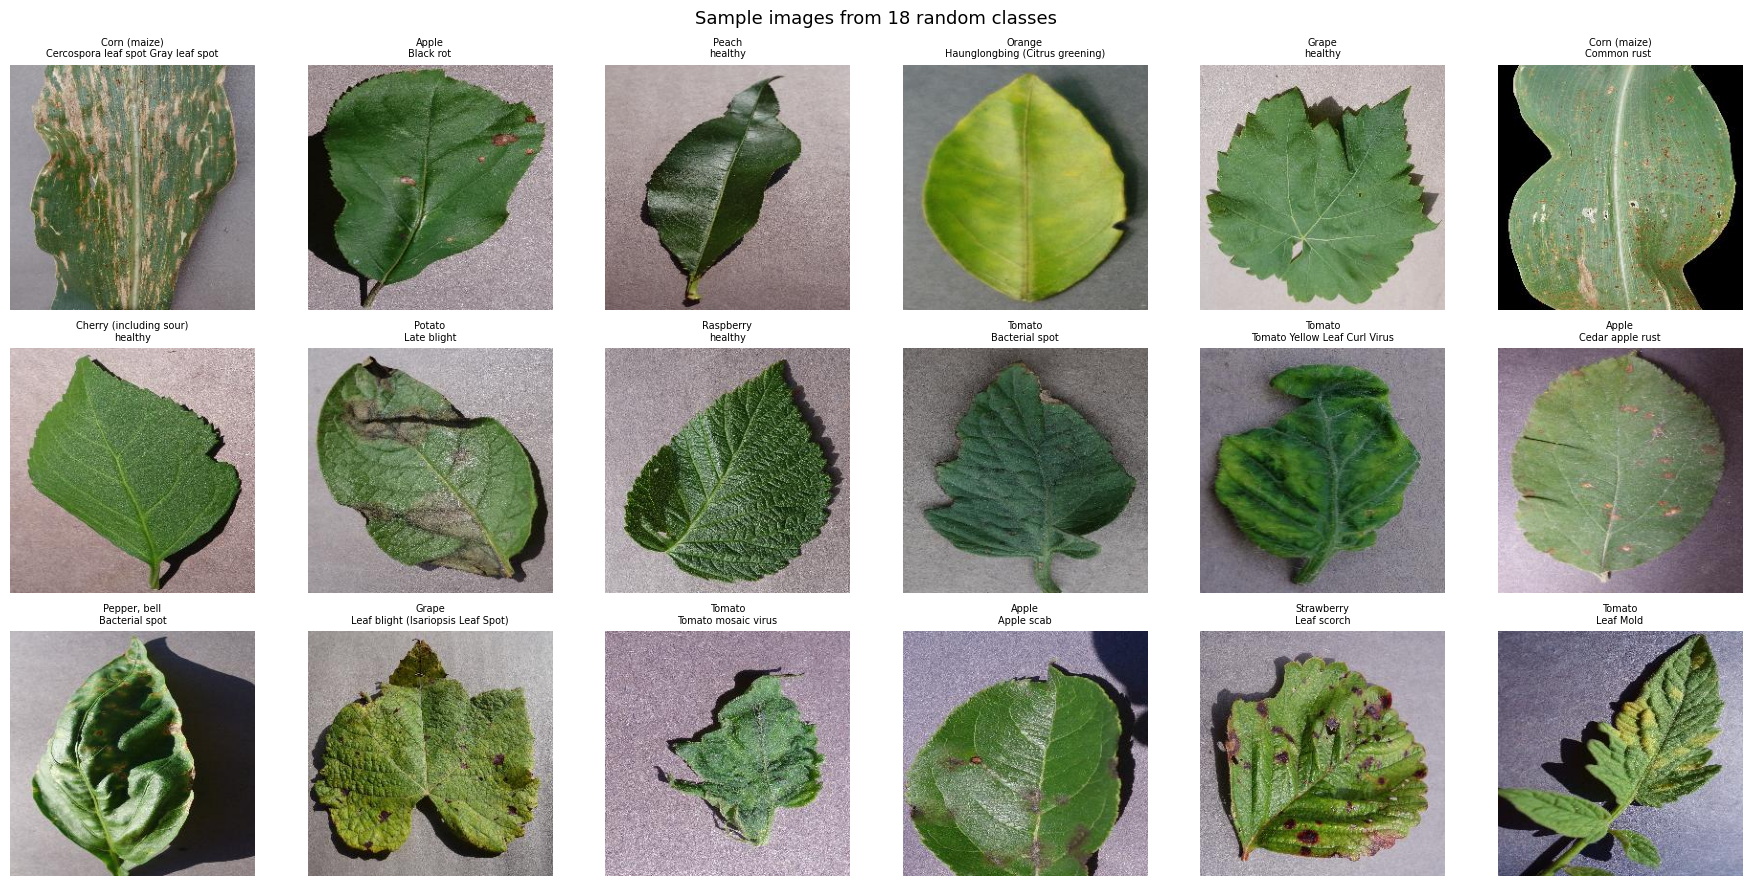

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
sample_classes = random.sample(sorted(os.listdir(DATASET_PATH)), 18)

for ax, cls in zip(axes.flat, sample_classes):
    img_path = random.choice(list((DATASET_PATH / cls).glob("*.jpg")))
    img = mpimg.imread(img_path)
    ax.imshow(img)
    label = cls.replace("___", "\n").replace("_", " ")
    ax.set_title(label, fontsize=7)
    ax.axis('off')

plt.suptitle("Sample images from 18 random classes", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("Checking image sizes and channels...\n")
sizes = []
channels_list = []
sample_paths = []

for cls in sorted(DATASET_PATH.iterdir()):
    imgs = list(cls.glob("*.jpg"))
    sample = random.sample(imgs, min(10, len(imgs)))
    sample_paths.extend(sample)

for path in sample_paths:
    img = Image.open(path)
    sizes.append(img.size)
    channels_list.append(len(img.getbands()))

size_counts = Counter(sizes)
print(f"Unique image sizes found: {len(size_counts)}")
print(f"Most common size: {size_counts.most_common(1)[0]}")
print(f"\nAll unique sizes: {list(size_counts.keys())[:10]}")
print(f"\nAll images RGB (3 channels): {all(c == 3 for c in channels_list)}")
print(f"Total images sampled: {len(sample_paths)}")

Checking image sizes and channels...

Unique image sizes found: 1
Most common size: ((256, 256), 380)

All unique sizes: [(256, 256)]

All images RGB (3 channels): True
Total images sampled: 380


In [8]:
corrupt = []

for cls in sorted(DATASET_PATH.iterdir()):
    imgs = list(cls.glob("*.jpg"))
    for img_path in imgs:
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception as e:
            corrupt.append((str(img_path), str(e)))

print(f"Corrupt images found: {len(corrupt)}")
if corrupt:
    for path, err in corrupt:
        print(f"  ✗ {path} — {err}")
else:
    print("No corrupt images found ✓")

Corrupt images found: 0
No corrupt images found ✓


In [9]:
def parse_class(name):
    parts = name.split("___")
    crop = parts[0].replace("_", " ").strip()
    disease = parts[1].replace("_", " ").strip() if len(parts) > 1 else "Unknown"
    return crop, disease

df[['crop', 'disease']] = df['class'].apply(lambda x: pd.Series(parse_class(x)))
df['is_healthy'] = df['disease'].str.lower() == 'healthy'

df.to_csv("dataset_summary.csv", index=False)
print("Saved dataset_summary.csv ✓")
print(f"\nUnique crops: {df['crop'].nunique()}")
print(f"Healthy classes: {df['is_healthy'].sum()}")
print(f"Diseased classes: {(~df['is_healthy']).sum()}")
print()
print(df[['crop', 'disease', 'is_healthy', 'count']].to_string())

Saved dataset_summary.csv ✓

Unique crops: 14
Healthy classes: 12
Diseased classes: 26

                       crop                               disease  is_healthy  count
0                    Orange       Haunglongbing (Citrus greening)       False   5507
1                    Tomato         Tomato Yellow Leaf Curl Virus       False   5357
2                   Soybean                               healthy        True   5090
3                     Peach                        Bacterial spot       False   2297
4                    Tomato                        Bacterial spot       False   2127
5                    Tomato                           Late blight       False   1908
6                    Squash                        Powdery mildew       False   1835
7                    Tomato                    Septoria leaf spot       False   1771
8                    Tomato  Spider mites Two-spotted spider mite       False   1676
9                     Apple                               heal

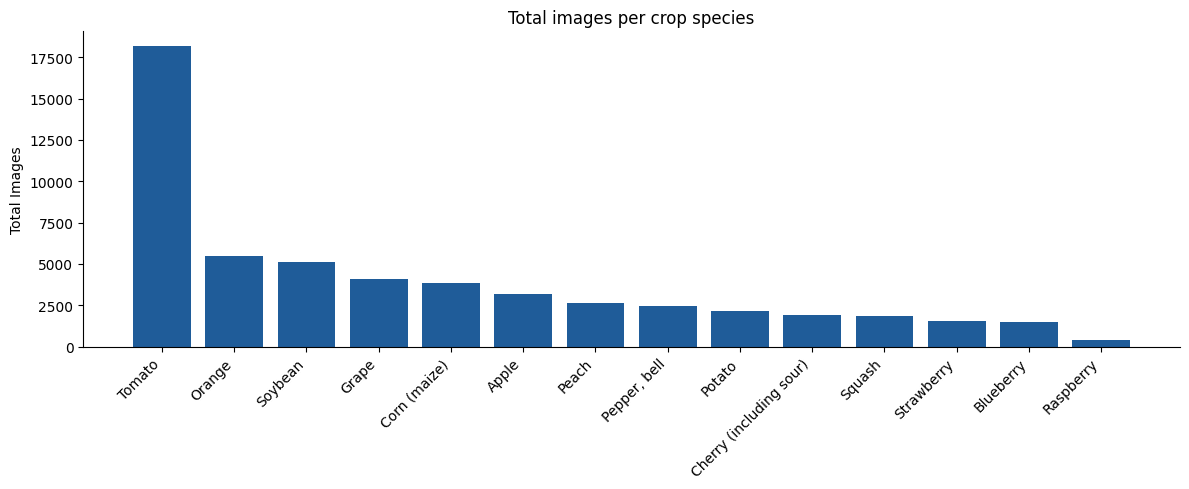

                         total_images  num_classes
crop                                              
Tomato                          18159           10
Orange                           5507            1
Soybean                          5090            1
Grape                            4062            4
Corn (maize)                     3852            4
Apple                            3171            4
Peach                            2657            2
Pepper, bell                     2474            2
Potato                           2152            3
Cherry (including sour)          1906            2
Squash                           1835            1
Strawberry                       1565            2
Blueberry                        1502            1
Raspberry                         371            1


In [10]:
crop_summary = df.groupby('crop').agg(
    total_images=('count', 'sum'),
    num_classes=('class', 'count')
).sort_values('total_images', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(crop_summary.index, crop_summary['total_images'], color='#1F5C99')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Total Images")
plt.title("Total images per crop species")
plt.tight_layout()
plt.savefig("crop_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(crop_summary.to_string())